In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import re
import string
from datetime import datetime, timedelta
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from lightgbm import LGBMRegressor

In [2]:
data_path = '/Users/kiyas/Documents/Programming_Practice/Rohlik-Orders-Forecasting/data'
checkpoint_path = 'checkpoint'

# Read train and test files
df = pd.read_csv(f'{data_path}/train.csv')
test = pd.read_csv(f'{data_path}/test.csv')

# Read calendar dataset
df_cld = pd.read_csv(f'{data_path}/train_calendar.csv')
test_cld = pd.read_csv(f'{data_path}/test_calendar.csv')

In [3]:
# convert the date column to datetime
df_cld['date'] = pd.to_datetime(df_cld['date'], errors='coerce')
test_cld['date'] = pd.to_datetime(test_cld['date'], errors='coerce')

df['date'] = pd.to_datetime(df['date'], errors='coerce')
test['date'] = pd.to_datetime(test['date'], errors='coerce')


#### EDA

In [5]:
%cd Rohlik-Orders-Forecasting

[Errno 2] No such file or directory: 'Rohlik-Orders-Forecasting'
/Users/kiyas/Documents/Programming_Practice/Rohlik-Orders-Forecasting


/Users/kiyas/Library/Python/3.10/lib/python/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


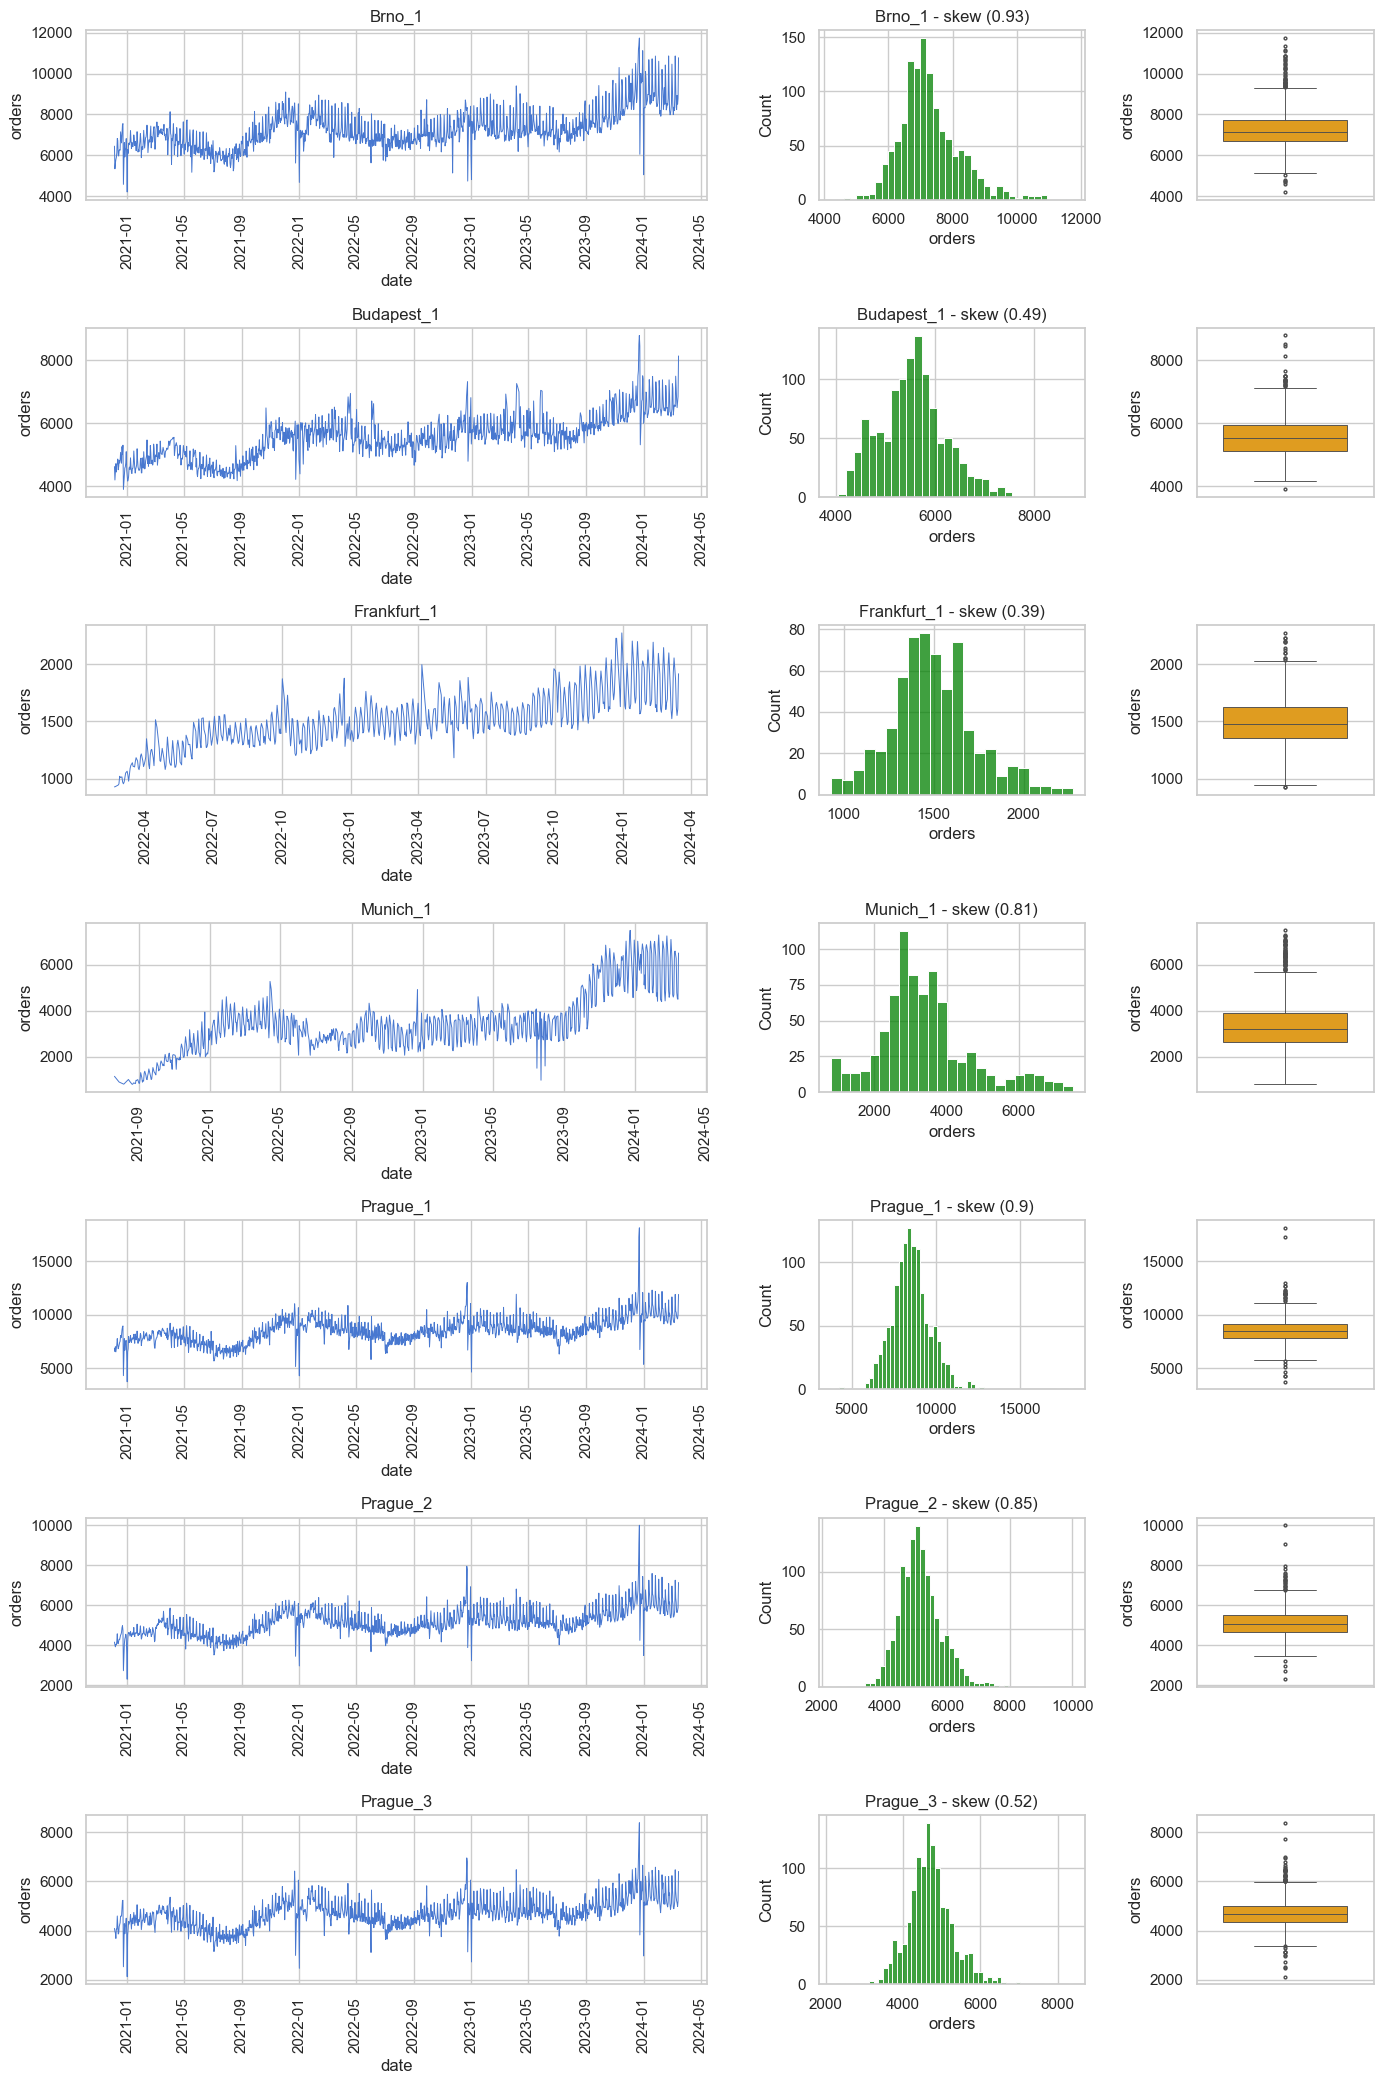

In [13]:
from visualize import *
sns.set_theme(style="whitegrid", palette="muted")
display_train_dist_by_warehouse(df)

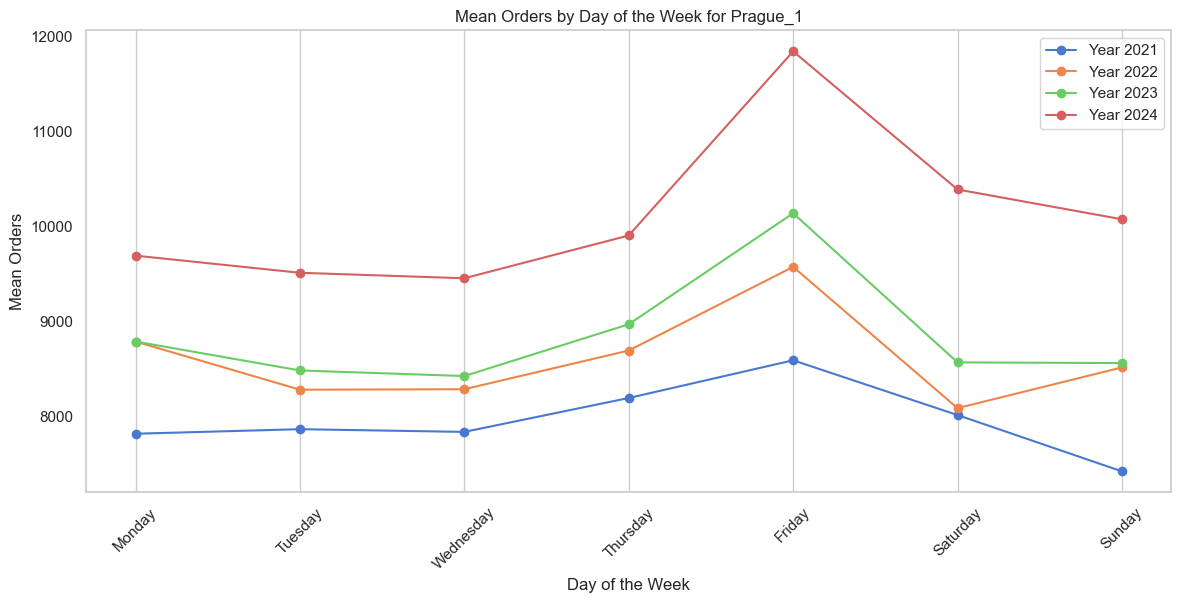

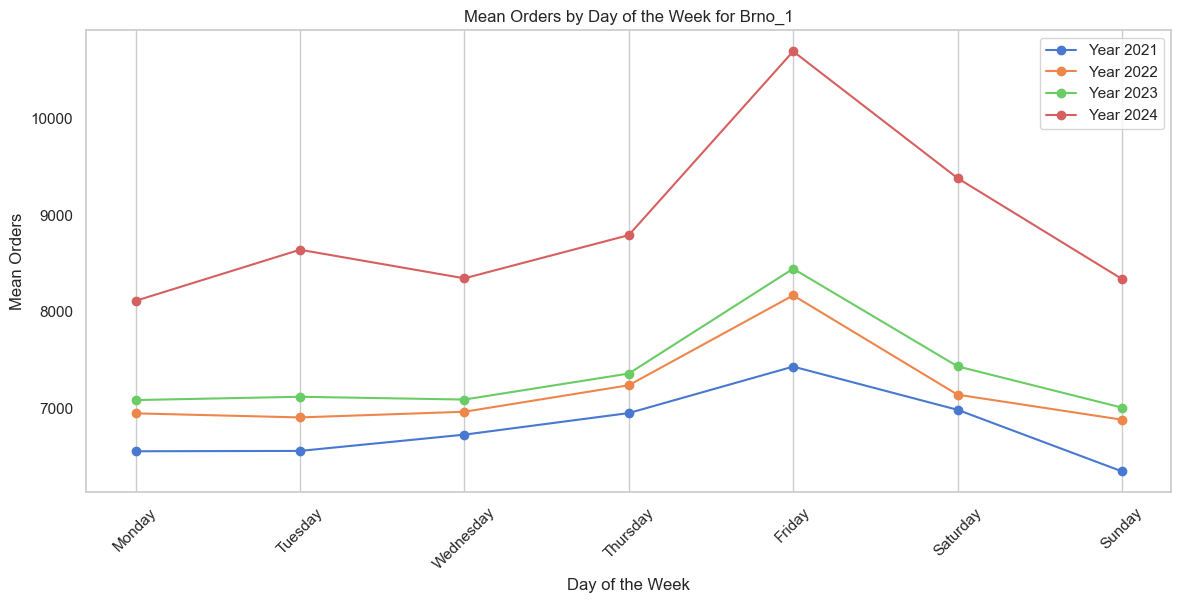

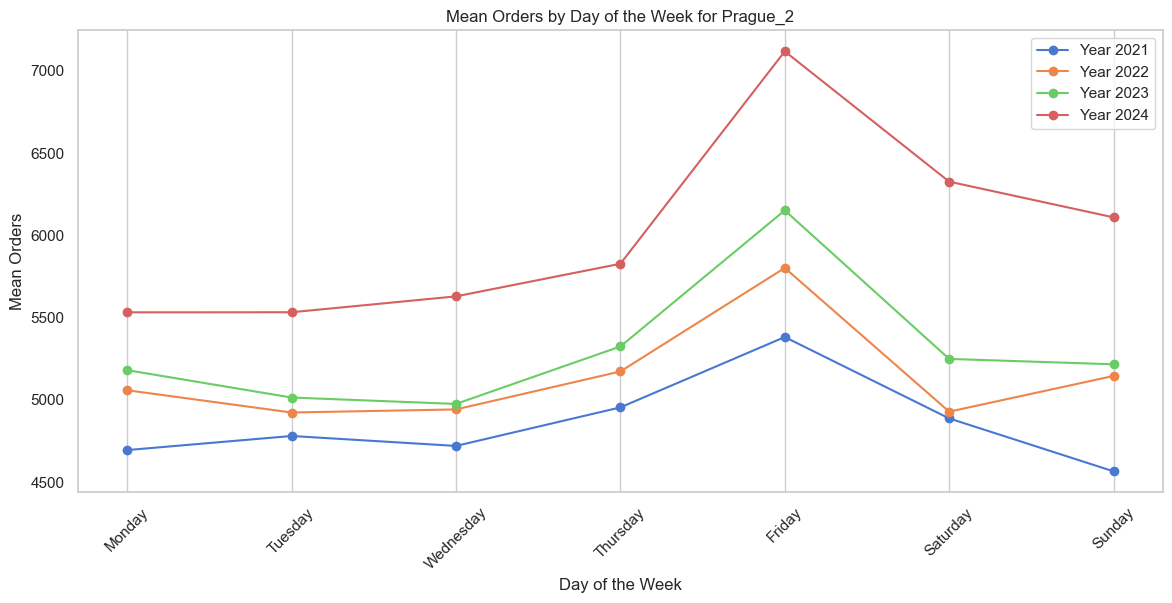

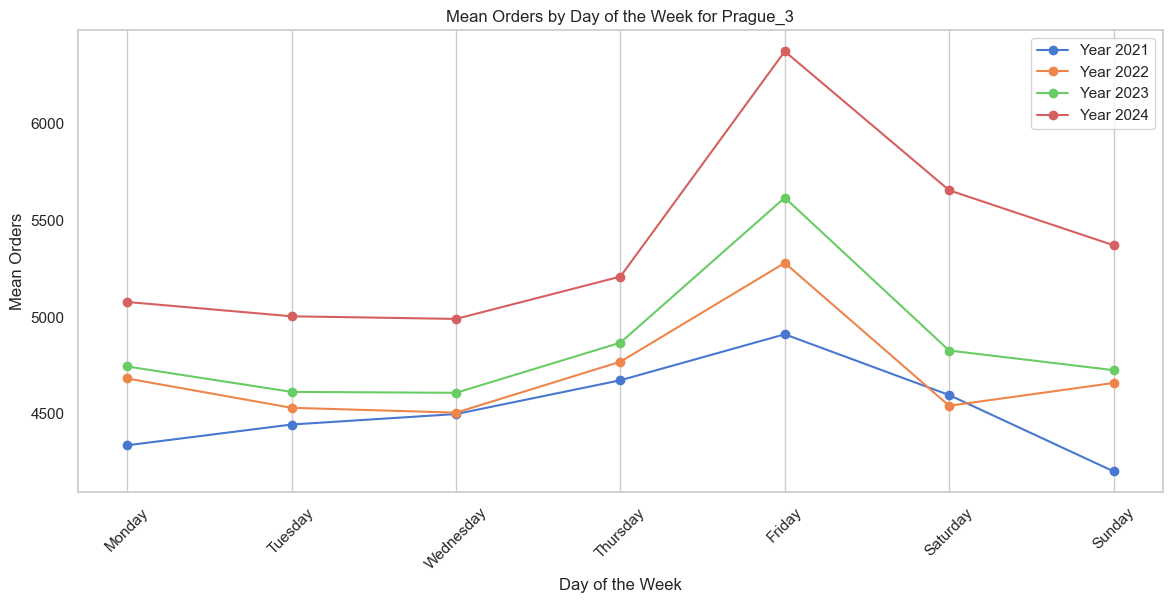

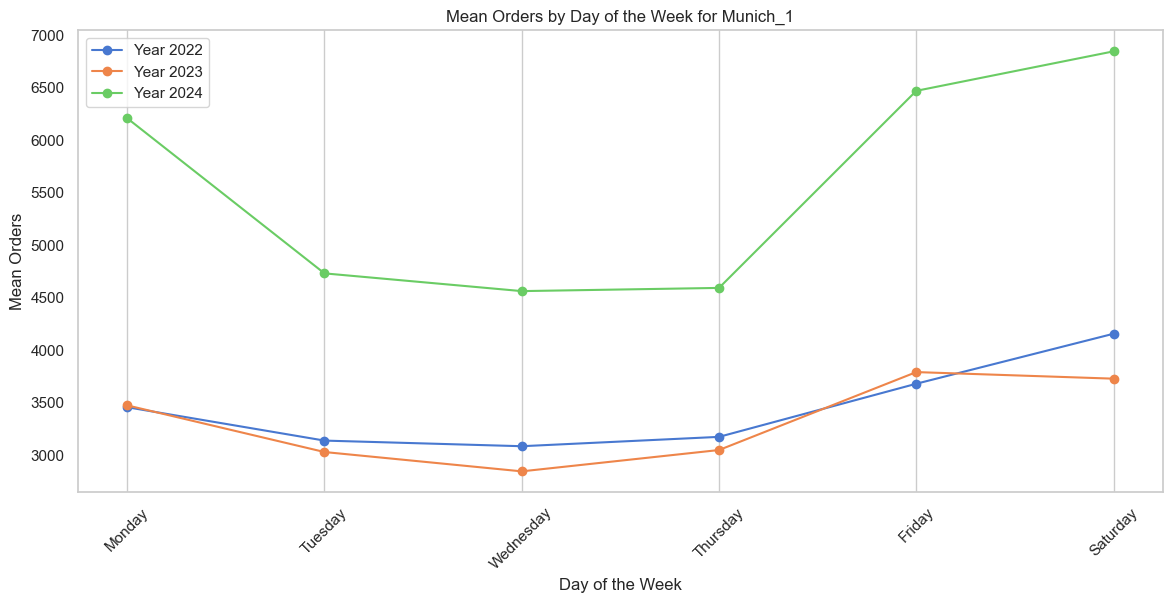

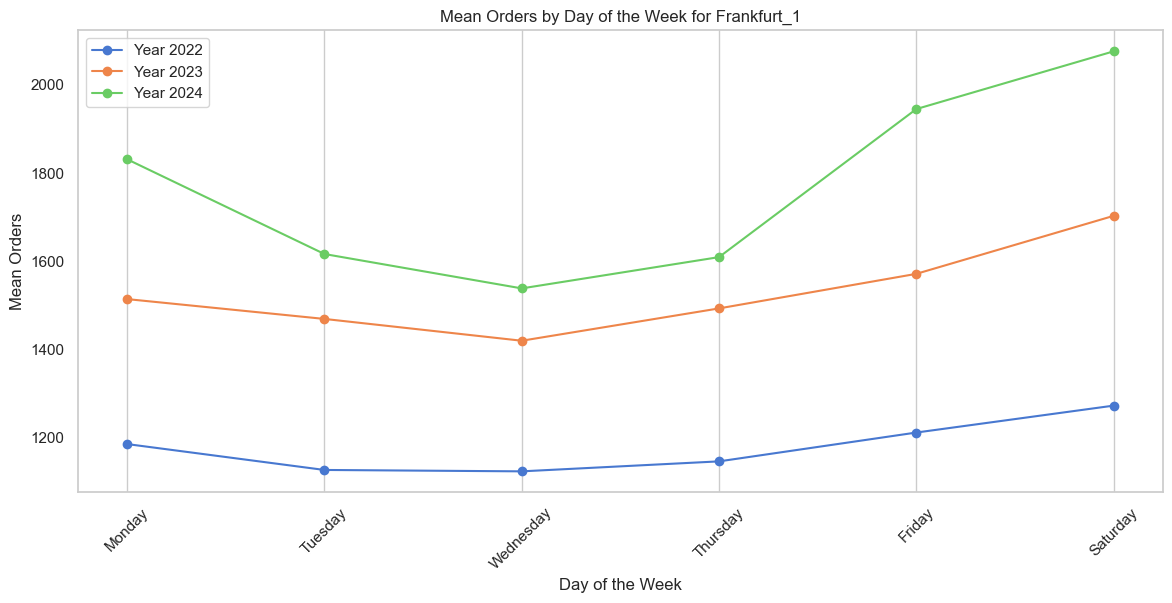

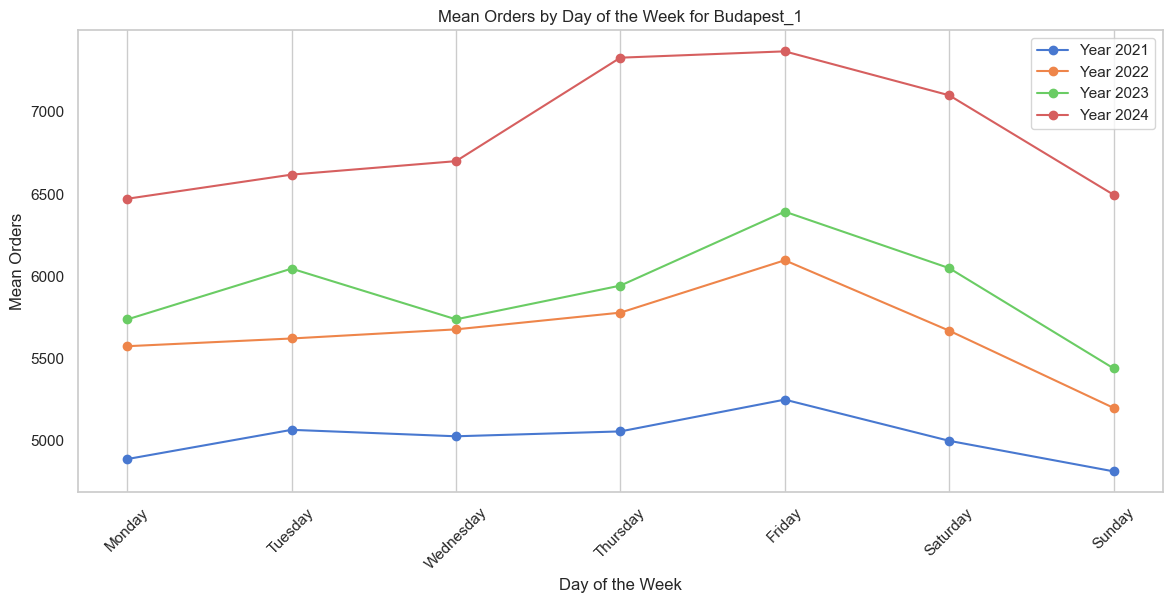

In [14]:
whs = df['warehouse'].unique()

# check mean order for day of the week on month 3,4,5
for wh in whs:
    display_mean_order(df, wh, month_list=[3, 4, 5])

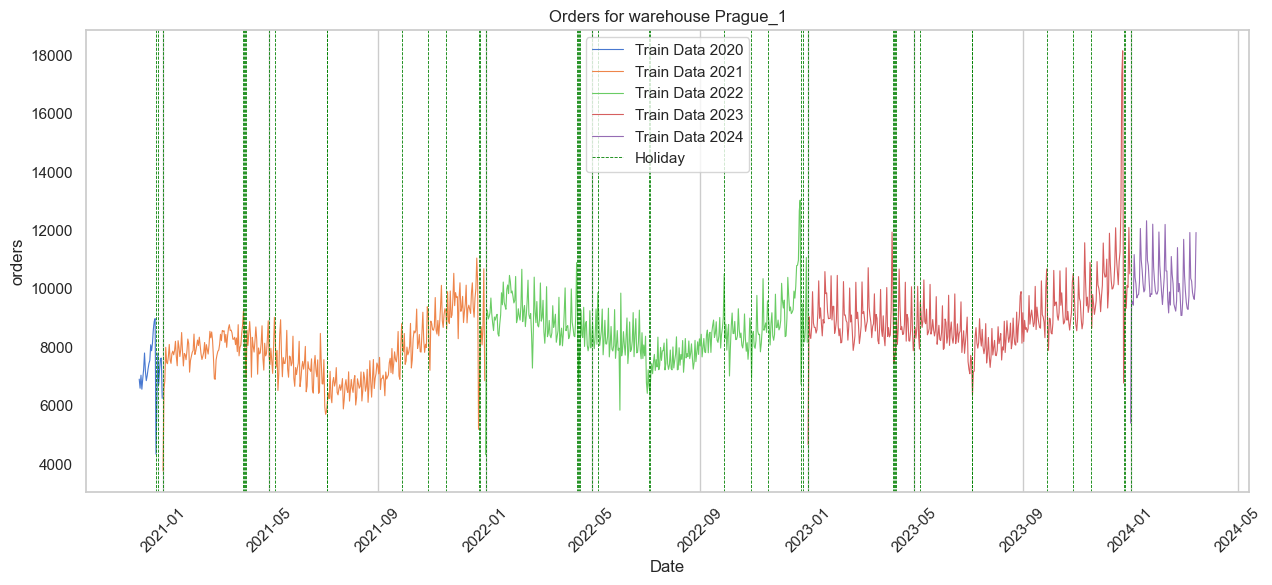

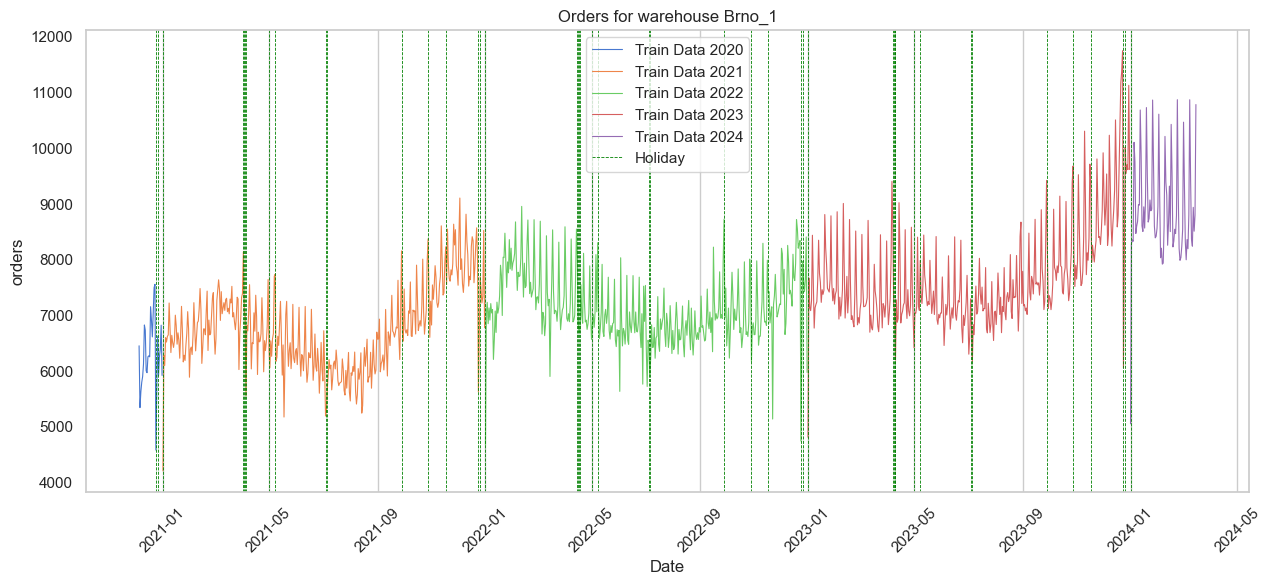

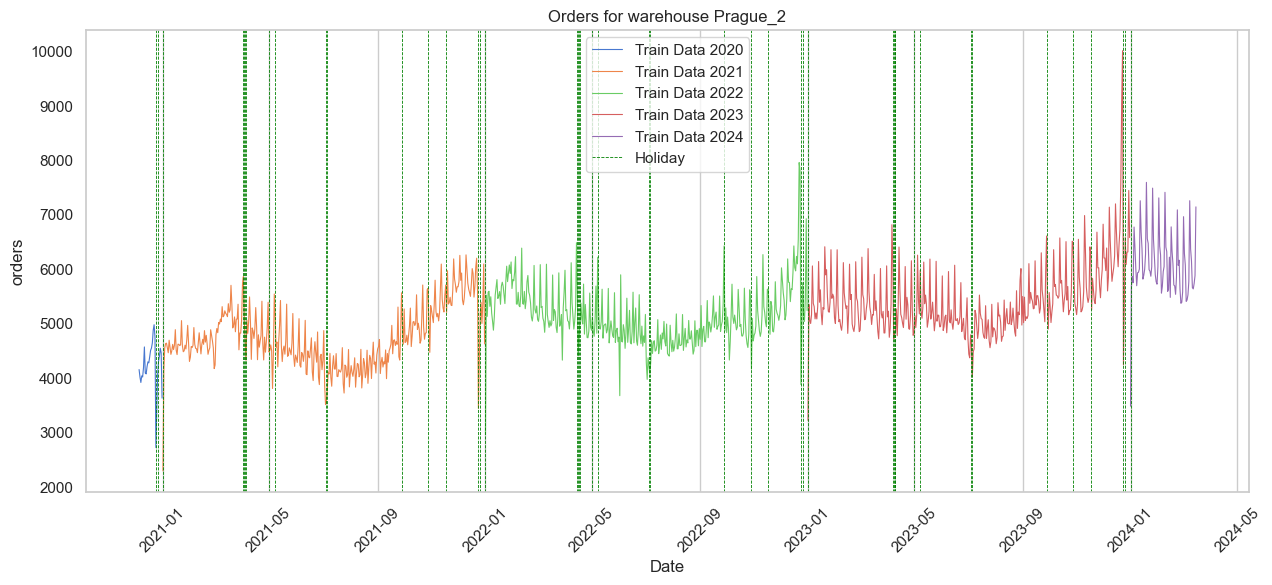

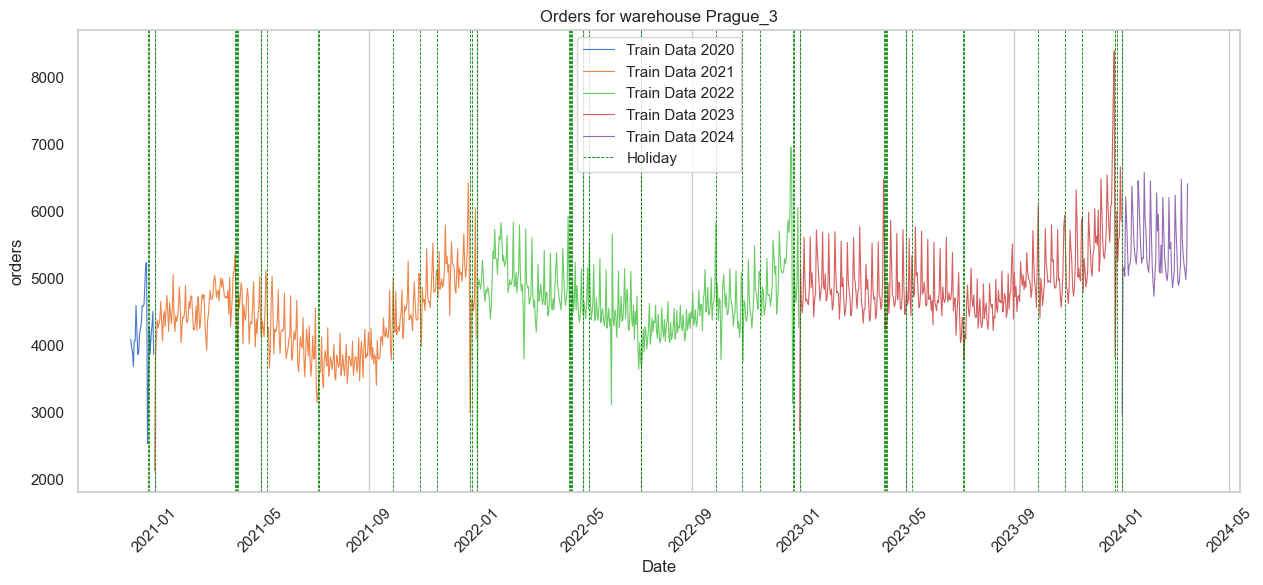

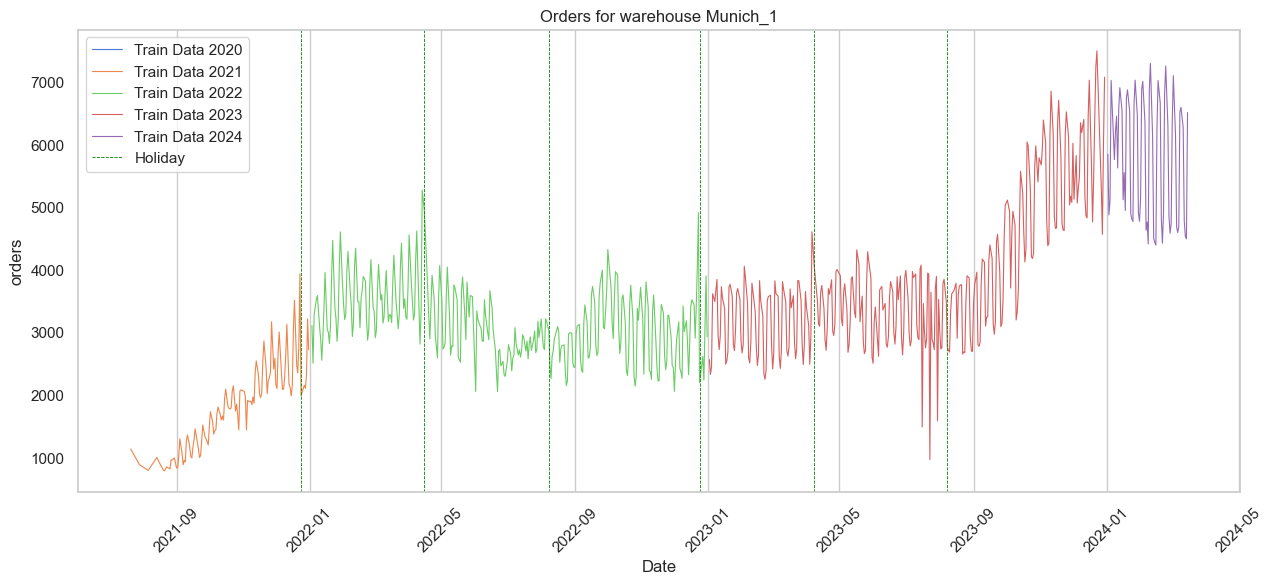

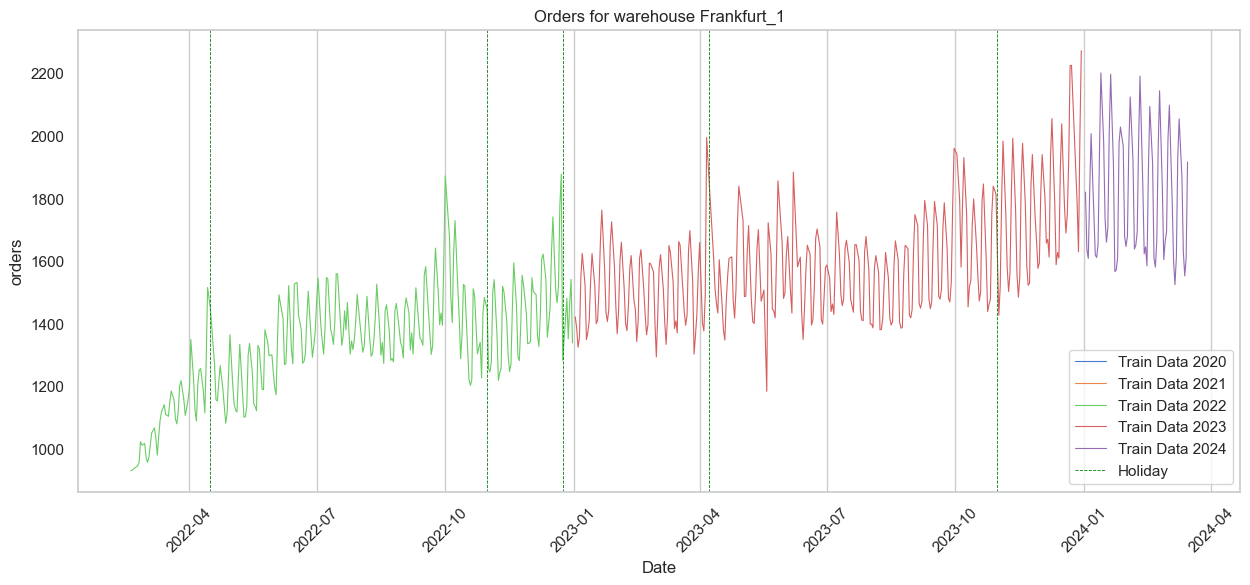

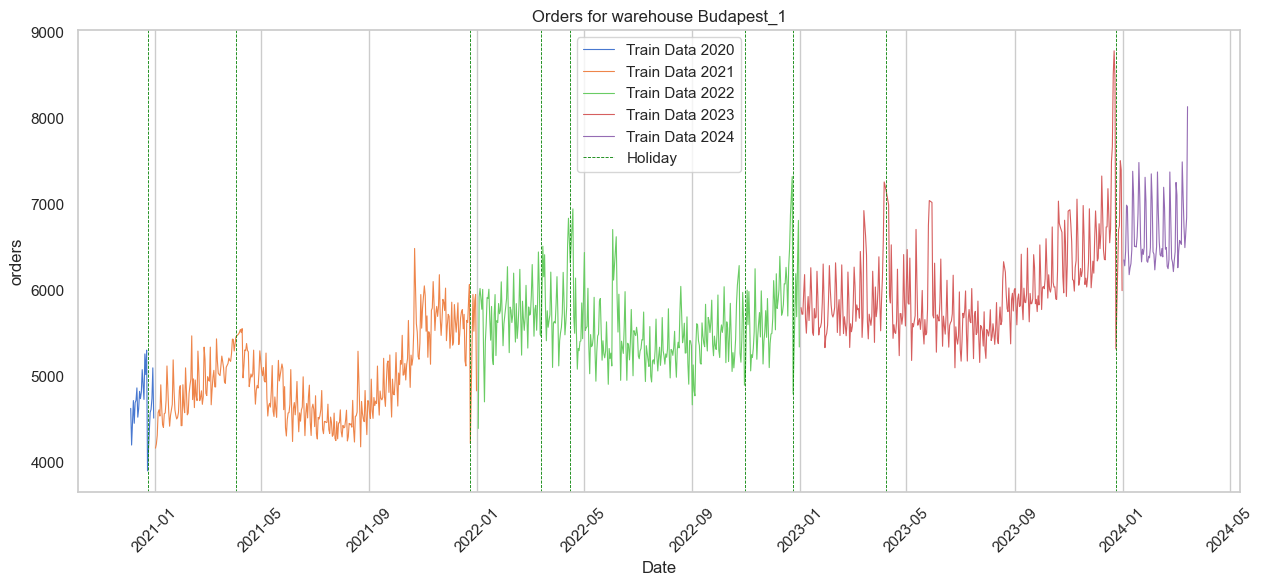

In [15]:
display_predictions(target_column = 'orders',
                    years=[2020,2021,2022,2023,2024],
                    plot_continue=False,
                    # force_holiday='Good Friday', # only show some days around Good Friday
                    force_holiday=None,
                    train_df=df,
                    use_submission=False)

#### preprocess

In [4]:
# import importlib
# import sys
# importlib.reload(sys.modules['preprocessing'])
from preprocessing import *

In [5]:
# Fill holidays and sort the dataframe
df_cld = cld_process(df_cld)
test_cld = cld_process(test_cld)

In [6]:
# Fill holidays from calender.csv to df
print('Dataframe train')
df = fill_calendar2df(df, df_cld)
print('Dataframe test')
test = fill_calendar2df(test, test_cld)

Dataframe train
Total holidays: 572
Total special holidays: 117
Dataframe test
Total holidays: 84
Total special holidays: 22


In [7]:
# Set special holidays for warehouses in Prague

datesx = ['03/31/2024', '04/09/2023', '04/17/2022', '04/04/2021', '04/12/2020']
# Convert the dates to datetime objects and subtract one day
holidaysx = [datetime.strptime(date, '%m/%d/%Y') - timedelta(days=1) for date in datesx]
# Define the list of warehouses
warehouses = ['Prague_1', 'Prague_2', 'Prague_3']
# Set 'holiday' to 1 for matching rows
df.loc[(df['date'].isin(holidaysx)) & (df['warehouse'].isin(warehouses)), 'holiday'] = 1
test.loc[(test['date'].isin(holidaysx)) & (test['warehouse'].isin(warehouses)), 'holiday'] = 1

In [8]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
tfidfvectorizer = TfidfVectorizer(max_features=3000)
feature_train, target_train, onehot_encoder, tfidfvectorizer = data_process(df, create_test_mode=False,
                                                                  target_cl=list(df.warehouse.unique()),
                                                                  onehot_encoder=onehot_encoder, tfidfvectorizer=tfidfvectorizer)

feature_test, testids = data_process(test, create_test_mode=True,
                                        target_cl=list(df.warehouse.unique()),
                                        onehot_encoder=onehot_encoder, tfidfvectorizer=tfidfvectorizer)


#### Prediction and Evaluation

In [9]:
def MAPE(y_true,y_pred):
    return np.mean(np.abs(y_pred-y_true)/y_true)

def pred_test(algo, X_train, y_train, X_test, exp_mode=False, **kwarg):
    if not exp_mode:
        model = algo.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        # Training on log features, help model more stable
        model = algo.fit(X_train, np.log1p(y_train))
        y_pred = np.expm1(model.predict(X_test))

    return y_pred, model

def save_submit(y_pred, save_dir=''):
    TARGET_COLUMNS = ['orders']
    prediction = pd.DataFrame(y_pred, columns=TARGET_COLUMNS)

    merged_prediction = pd.concat([testids, prediction], axis=1)
    merged_prediction = merged_prediction.reset_index(drop=True)
    merged_prediction.to_csv(f"{save_dir}/submission.csv",index=False)
    return merged_prediction


def fit_ml_algo(algo, X_train, y_train, X_test, y_test, exp_mode=False):
    if not exp_mode:
        model = algo.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model = algo.fit(X_train, np.log1p(y_train))
        y_pred = np.expm1(model.predict(y_train))
    mape = MAPE(y_test,y_pred)
    print("MAPE:", mape)

    return y_pred, model

##### Single LGBM

In [37]:
# hyperparameter tune by optuna
best_hypr = {'reg_alpha': 0.22395576225297806,
             'reg_lambda': 0.013055491064310818,
             'learning_rate': 0.48284825276236043,
             'colsample_bytree': 0.7922000123536603,
             'min_child_weight': 0.00010297333065138669,
             'num_leaves': 14,
             'min_child_samples': 10}

# model = LGBMRegressor(importance;_type='gain', min_child_samples=9, n_estimators=100, force_col_wise=True)
model = LGBMRegressor(objective='regression_l1', n_estimators=600, **best_hypr)
y_pred, model = pred_test(model, feature_train, target_train.values.ravel(), feature_test, exp_mode=True)

print(y_pred.mean())

y_pred_self = np.expm1(model.predict(feature_train))
print('Self fit loss:', MAPE(target_train.values.ravel(), y_pred_self))

submit_df = save_submit(y_pred, save_dir=checkpoint_path)
submit_df_c = submit_df.copy()
# df.to_csv(f'{checkpoint_path}/df_temp.csv')
# test.to_csv(f'{checkpoint_path}/test_temp.csv')
# 0.021298697136921178

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 304
[LightGBM] [Info] Number of data points in the train set: 7340, number of used features: 52
[LightGBM] [Info] Start training from score 8.588769
6497.903819154564
Self fit loss: 0.019375323983753155


###### feature importance

/var/folders/vk/mc7fb_h96kv3q9yslvjf_1200000gn/T/ipykernel_69820/1135937307.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=lgbm_importances.index, x=lgbm_importances.values, orient='h', palette=palette)


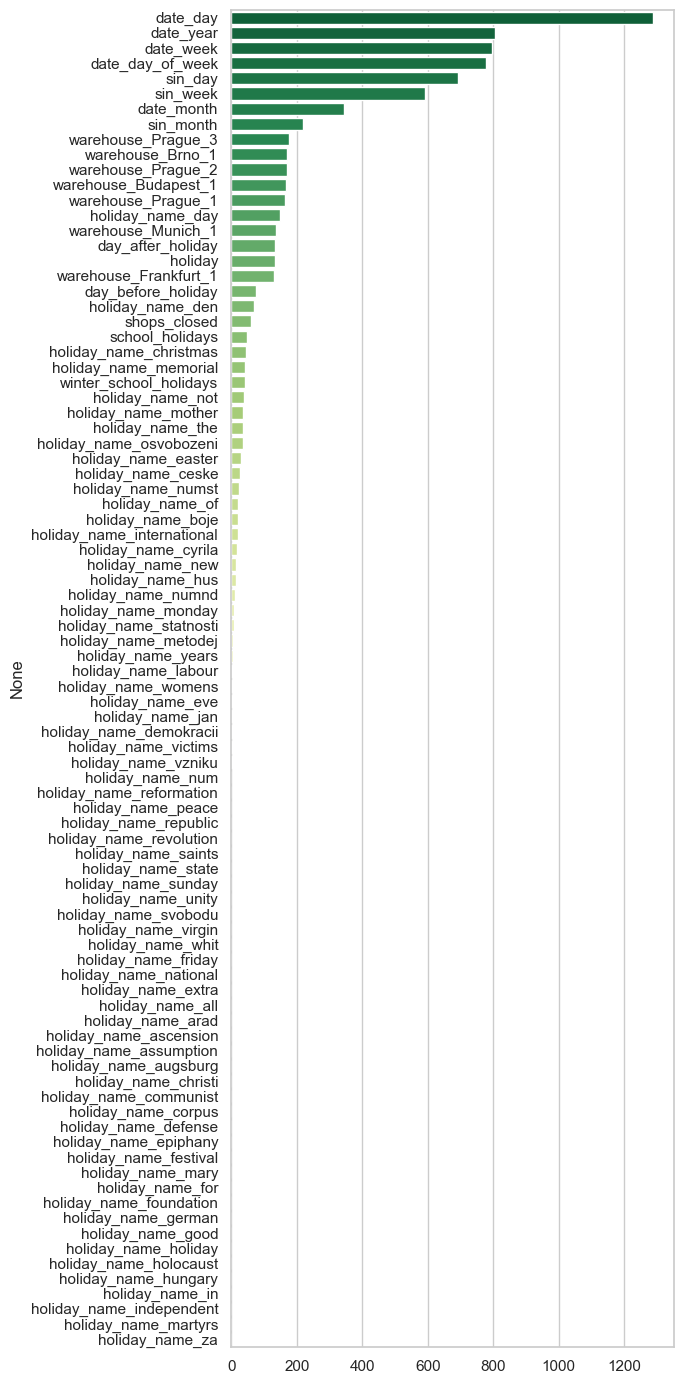

In [38]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axs = plt.subplots(1, 1, figsize=(7, 14))
palette = sns.color_palette("RdYlGn_r", len(feature_train.columns))
lgbm_importances = pd.Series(model.feature_importances_, index=feature_train.columns).sort_values(ascending=False)
sns.barplot(y=lgbm_importances.index, x=lgbm_importances.values, orient='h', palette=palette)

plt.tight_layout()
plt.show()

###### Final prediction plot

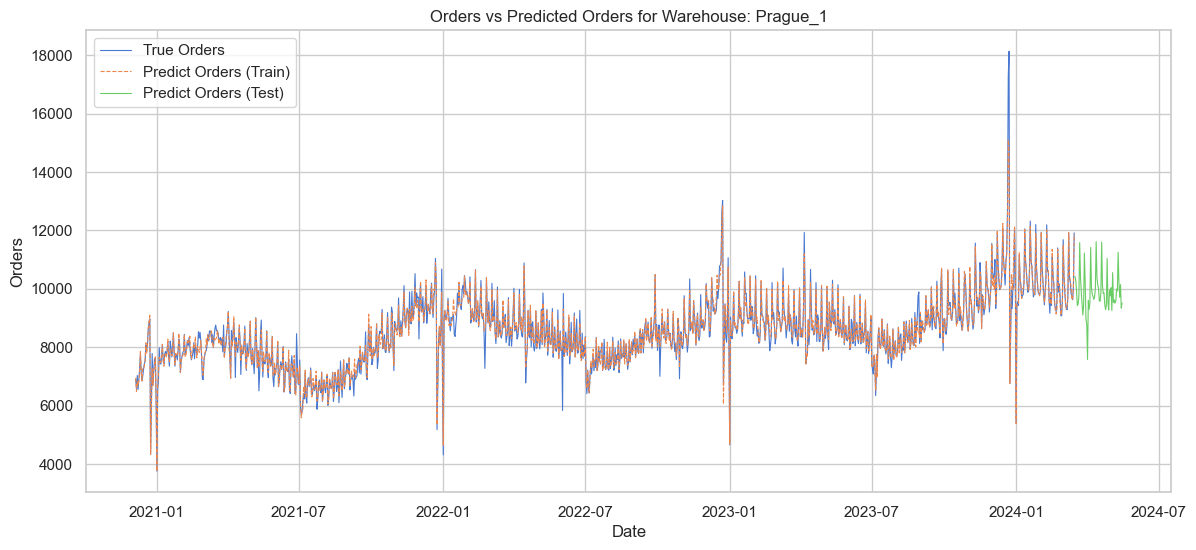

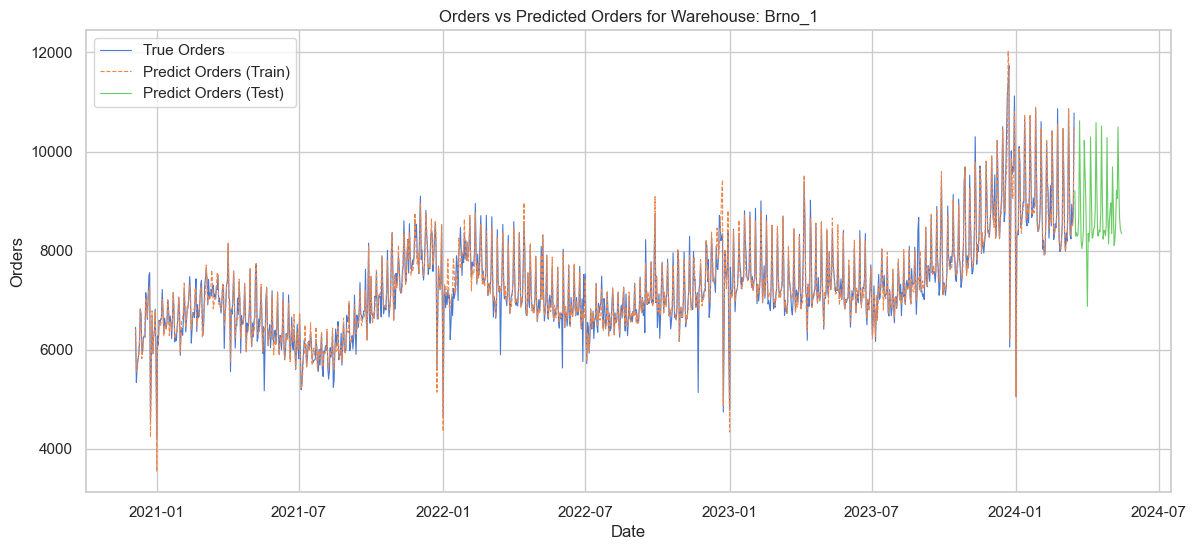

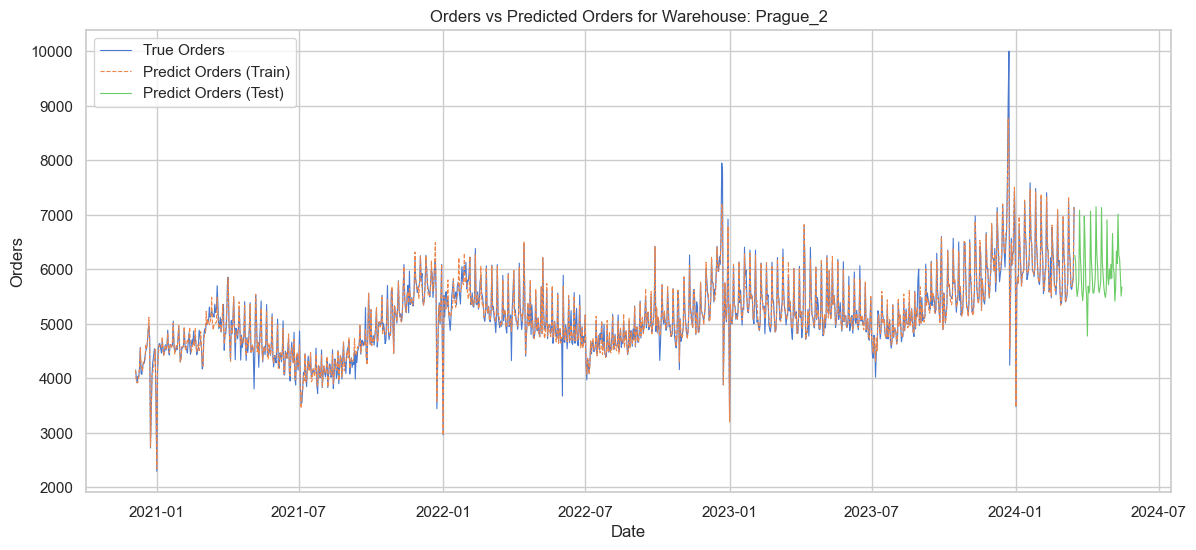

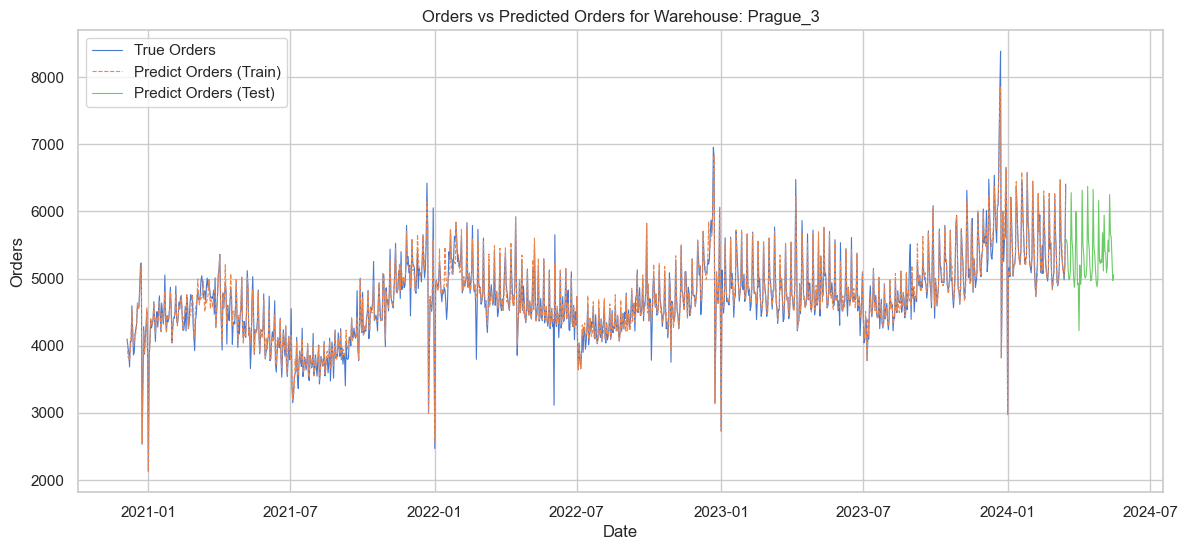

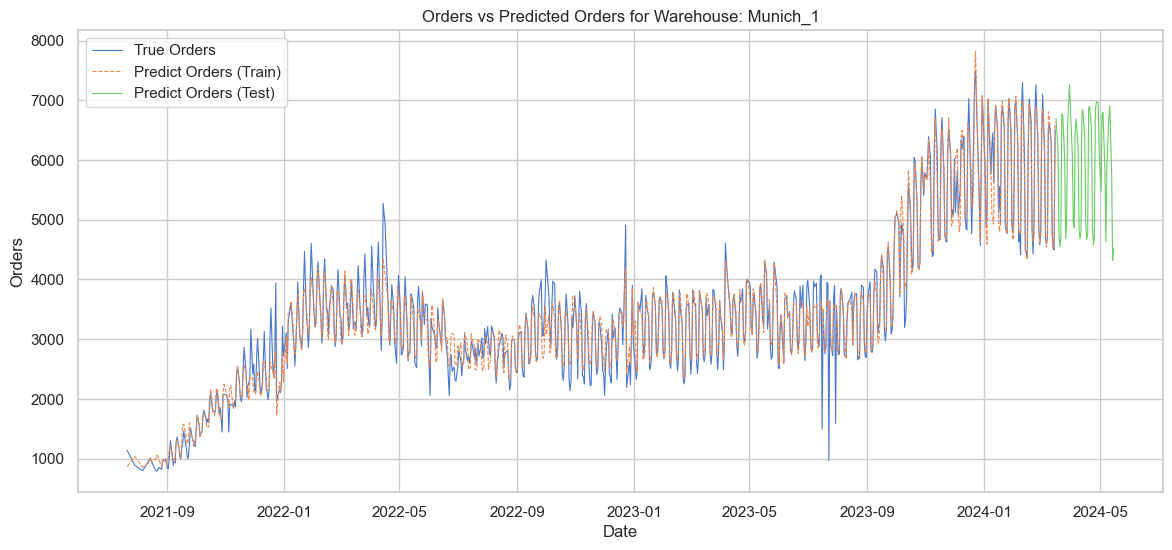

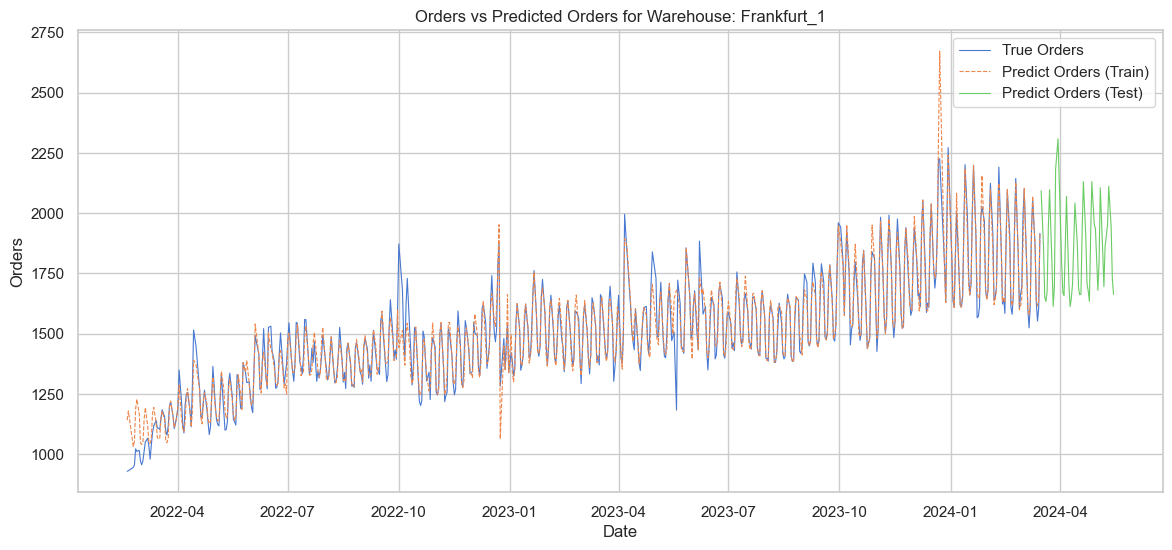

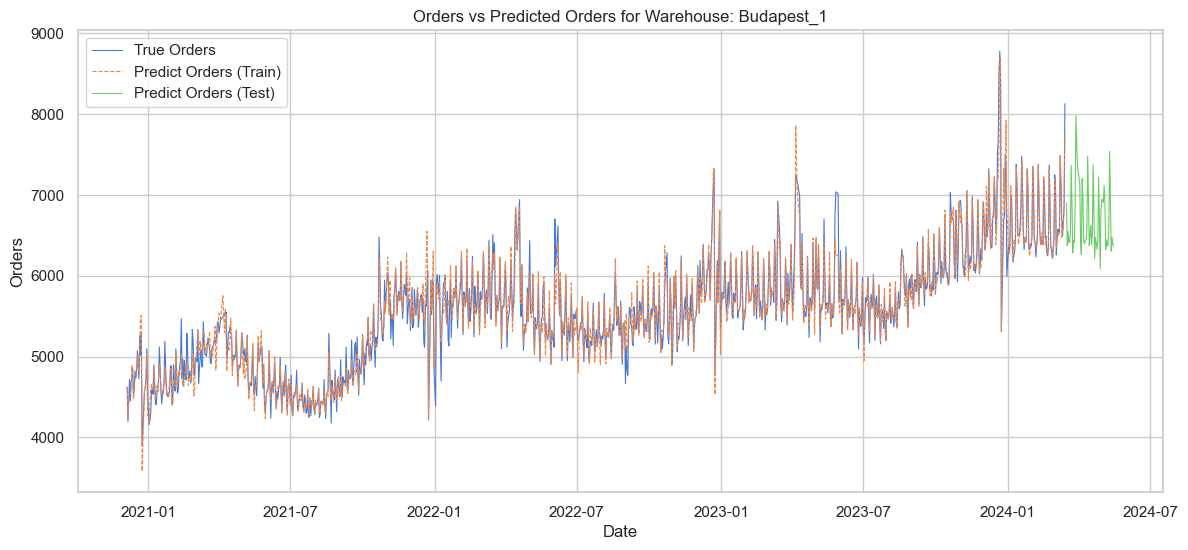

In [26]:
# df = df_ori.copy()
df['y_pred_self'] = y_pred_self

df.set_index('date', inplace=True)

# Extract 'warehouse' and 'date' from 'id'
submit_df = submit_df_c.copy()
submit_df['warehouse'] = submit_df['id'].apply(lambda x: x.rsplit('_', maxsplit=1)[0])
submit_df['date'] = submit_df['id'].apply(lambda x: x.split('_')[-1])
submit_df['date'] = pd.to_datetime(submit_df['date'])

submit_df.set_index('date', inplace=True)

for warehouse in df['warehouse'].unique():

    df_warehouse = df[df['warehouse'] == warehouse]
    submit_warehouse = submit_df[submit_df['warehouse'] == warehouse]

    plt.figure(figsize=(14, 6))

    # True orders from the training data
    plt.plot(df_warehouse.index, df_warehouse['orders'], label='True Orders', linewidth=0.8)

    # Predicted orders of the training data
    plt.plot(df_warehouse.index, df_warehouse['y_pred_self'], label='Predict Orders (Train)', linestyle='--', linewidth=0.8)

    # Predicted orders of the test set
    plt.plot(submit_warehouse.index, submit_warehouse['orders'], label='Predict Orders (Test)', linestyle='-', linewidth=0.8)

    plt.title(f'Orders vs Predicted Orders for Warehouse: {warehouse}')
    plt.xlabel('Date')
    plt.ylabel('Orders')
    plt.legend()
    plt.show()

##### Ensemble - Voting

In [26]:
import sklearn
# from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor

best_hypr = {'reg_alpha': 0.22395576225297806,
             'reg_lambda': 0.013055491064310818,
             'learning_rate': 0.48284825276236043,
             'colsample_bytree': 0.7922000123536603,
             'min_child_weight': 0.00010297333065138669,
             'num_leaves': 14,
             'min_child_samples': 10}
def make_model(seed = 42):
    lgbm_model = LGBMRegressor(objective='regression_l1', n_estimators=600, seed = seed, **best_hypr)


    lgbm_model2 = LGBMRegressor(      
                    n_estimators = 650,
                    learning_rate = 0.05,
                    reg_alpha = 0.1,
                    reg_lambda = 0.1,
                    num_leaves = 15,
                    seed = seed
                            )
    
    gb_model = GradientBoostingRegressor(
        n_estimators= 600,
        max_depth=10,
        learning_rate=0.05,
        random_state = seed
        )

    gb_model2 = GradientBoostingRegressor(
        n_estimators= 700,
        max_depth=8,
        learning_rate=0.1,
        random_state = seed
        )

    return sklearn.ensemble.VotingRegressor([("lgbm", lgbm_model), ("gb", gb_model), ("lgbm2", lgbm_model2), ("gb2", gb_model2)])

In [30]:
model = make_model()
y_pred, model = pred_test(model, feature_train, target_train.values.ravel(), feature_test, exp_mode=True)

print(y_pred.mean())

y_pred_self = np.expm1(model.predict(feature_train))
print('Self fit loss:', MAPE(target_train.values.ravel(), y_pred_self))

submit_df = save_submit(y_pred, save_dir=checkpoint_path)
submit_df_c = submit_df.copy()

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 7340, number of used features: 48
[LightGBM] [Info] Start training from score 8.588769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 163
[LightGBM] [Info] Number of data points in the train set: 7340, number of used features: 42
[LightGBM] [Info] Start training from score 8.515842


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


6439.808989469902
Self fit loss: 0.014428690226091409


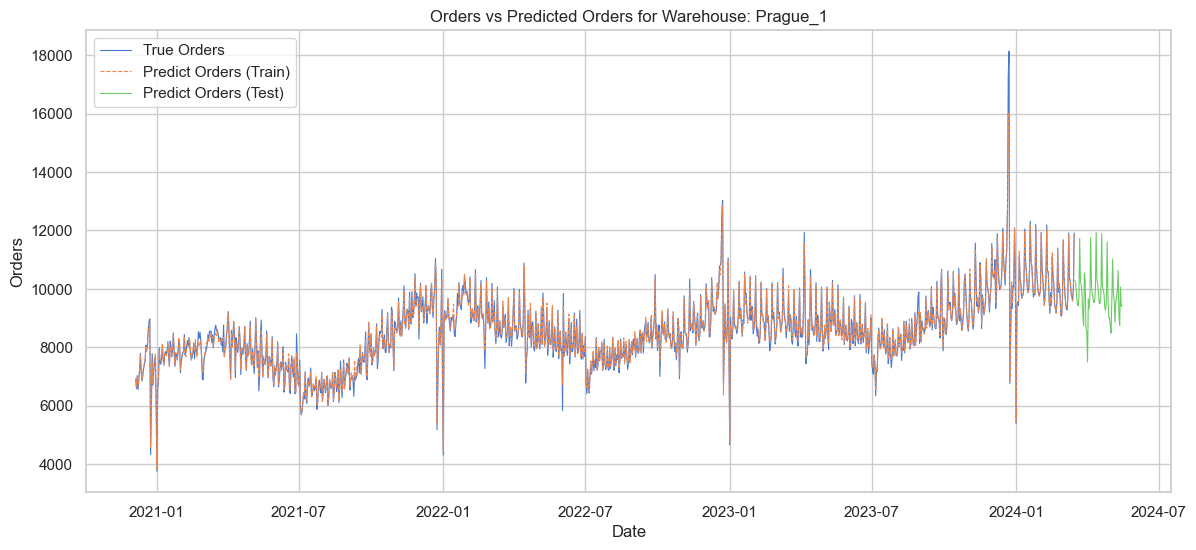

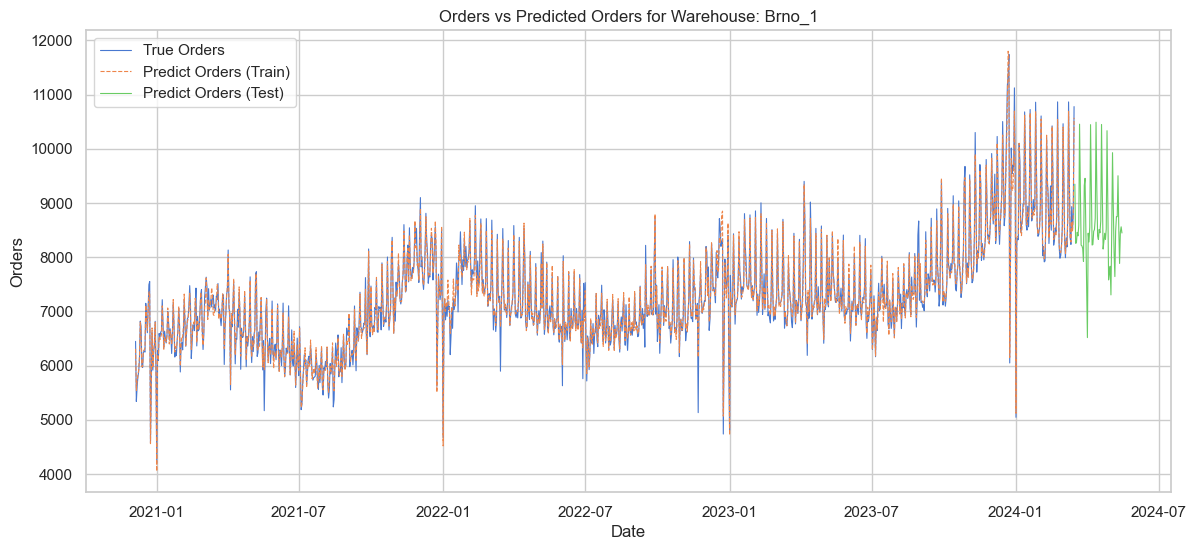

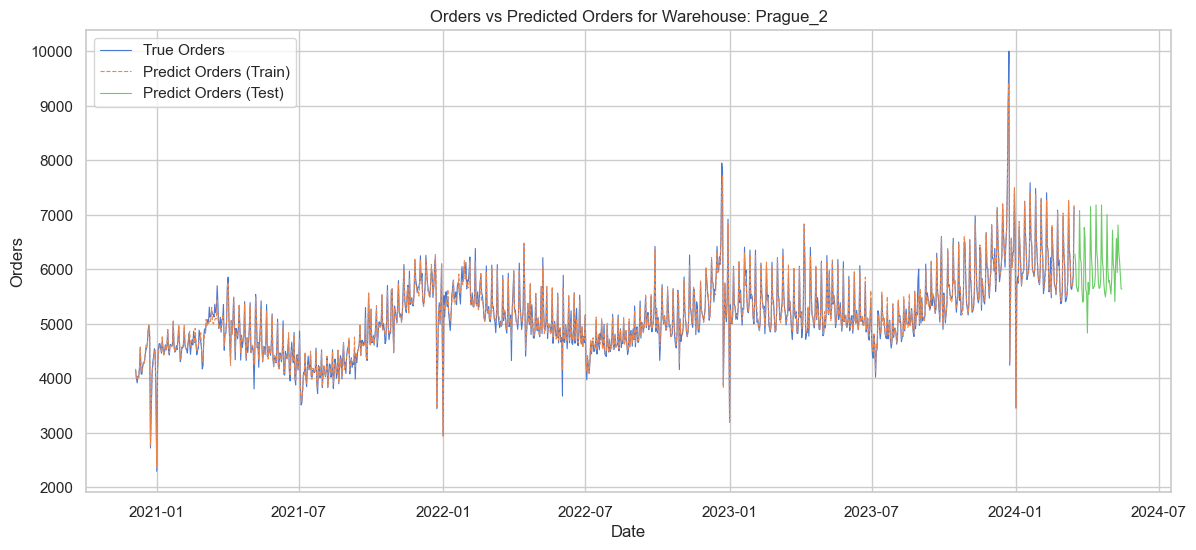

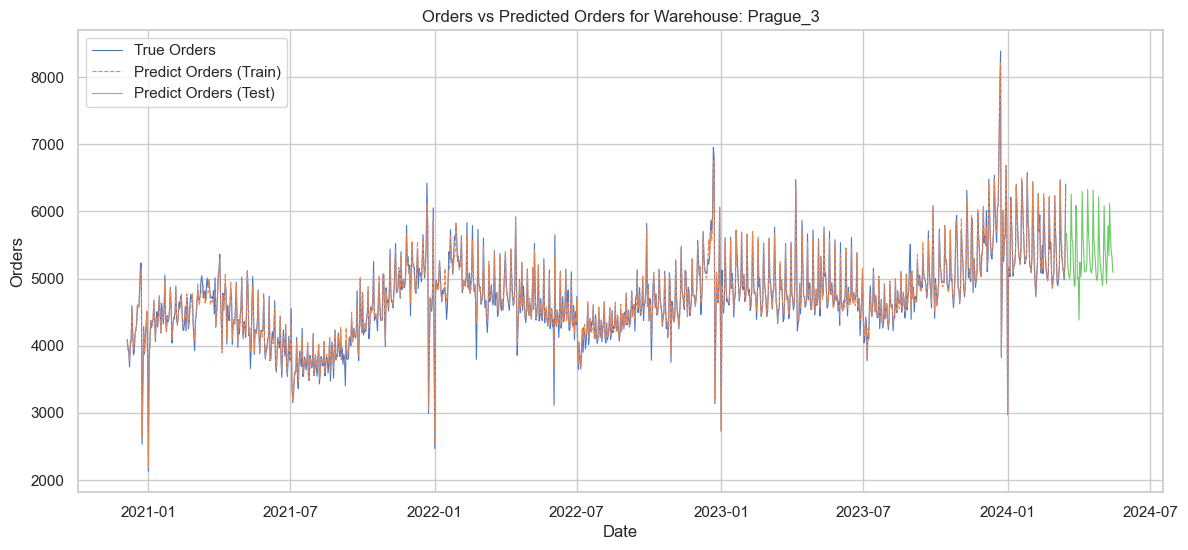

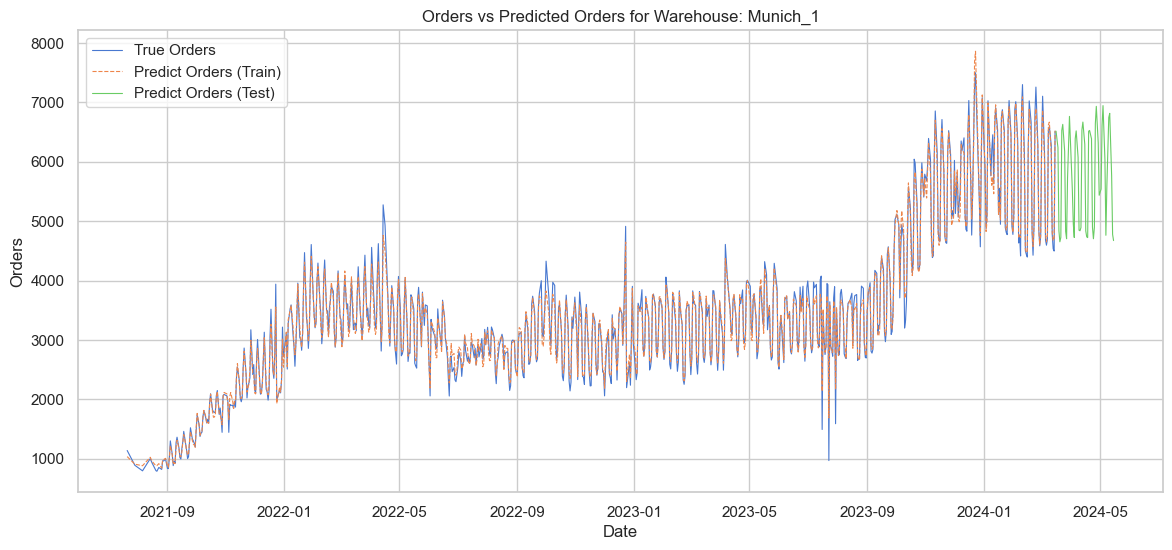

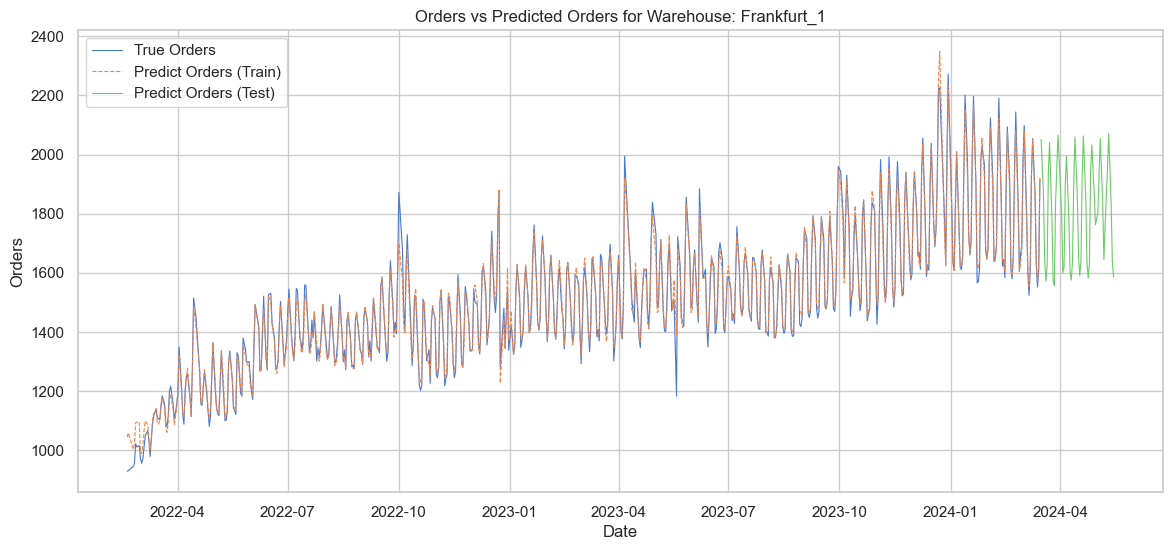

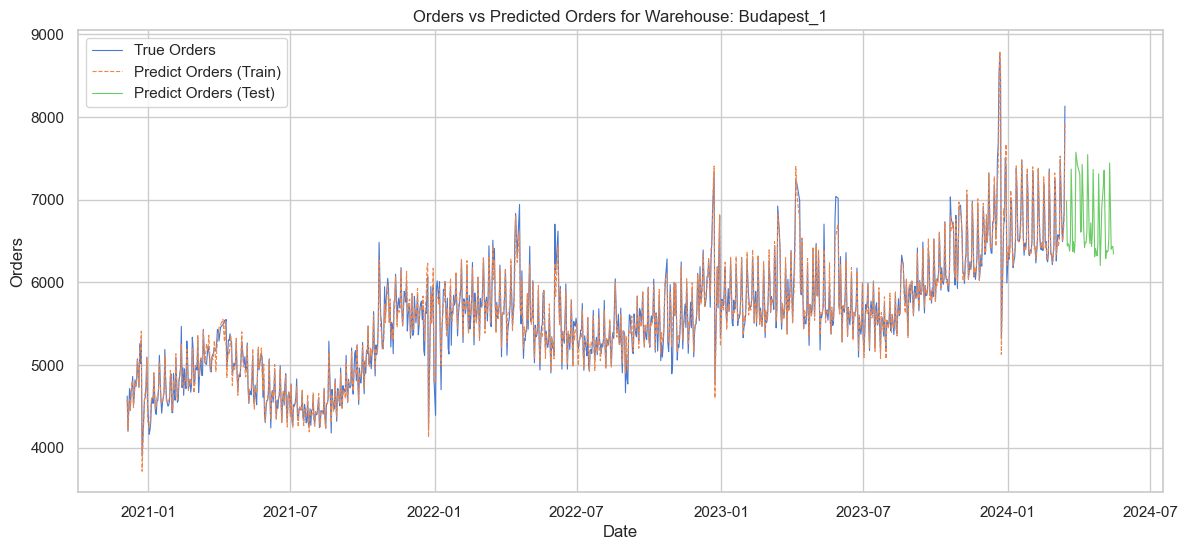

In [ ]:
# df = df_ori.copy()
sns.set_theme(style="whitegrid", palette="muted")
df['y_pred_self'] = y_pred_self

df.set_index('date', inplace=True)

# Extract 'warehouse' and 'date' from 'id'
submit_df = submit_df_c.copy()
submit_df['warehouse'] = submit_df['id'].apply(lambda x: x.rsplit('_', maxsplit=1)[0])
submit_df['date'] = submit_df['id'].apply(lambda x: x.split('_')[-1])
submit_df['date'] = pd.to_datetime(submit_df['date'])

submit_df.set_index('date', inplace=True)

for warehouse in df['warehouse'].unique():

    df_warehouse = df[df['warehouse'] == warehouse]
    submit_warehouse = submit_df[submit_df['warehouse'] == warehouse]

    plt.figure(figsize=(14, 6))

    # True orders from the training data
    plt.plot(df_warehouse.index, df_warehouse['orders'], label='True Orders', linewidth=0.8)

    # Predicted orders of the training data
    plt.plot(df_warehouse.index, df_warehouse['y_pred_self'], label='Predict Orders (Train)', linestyle='--', linewidth=0.8)

    # Predicted orders of the test set
    plt.plot(submit_warehouse.index, submit_warehouse['orders'], label='Predict Orders (Test)', linestyle='-', linewidth=0.8)

    plt.title(f'Orders vs Predicted Orders for Warehouse: {warehouse}')
    plt.xlabel('Date')
    plt.ylabel('Orders')
    plt.legend()
    plt.show()